In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("autunno/15-years-of-power-outages")

print("Path to dataset files:", path)

In [ ]:
import os

os.listdir(path)  #achar o nome do arquivo

In [13]:
import pandas as pd

# converter com proteção contra erro
df['Date Event Began'] = pd.to_datetime(df['Date Event Began'], errors='coerce')
df['Date of Restoration'] = pd.to_datetime(df['Date of Restoration'], errors='coerce')

In [15]:
df['OUTAGE.DURATION'] = (df['Date of Restoration'] - df['Date Event Began']).dt.total_seconds() / 3600

In [7]:
import pandas as pd

df = pd.read_csv(path + "/Grid_Disruption_00_14_standardized - Grid_Disruption_00_14_standardized.csv")
df.head()  #ler o nome do arquivo e exibilo

,Event Description,Year,Date Event Began,Time Event Began,Date of Restoration,Time of Restoration,Respondent,Geographic Areas,NERC Region,Demand Loss (MW),Number of Customers Affected,Tags
0,Severe Weather - Thunderstorms,2014,6/30/2014,8:00 PM,7/2/2014,6:30 PM,Exelon Corporation/ComEd,Illinois,RFC,Unknown,"420,000","severe weather, thunderstorm"
1,Severe Weather - Thunderstorms,2014,6/30/2014,11:20 PM,7/1/2014,5:00 PM,Northern Indiana Public Service Company,North Central Indiana,RFC,Unknown,"127,000","severe weather, thunderstorm"
2,Severe Weather - Thunderstorms,2014,6/30/2014,5:55 PM,7/1/2014,2:53 AM,We Energies,Southeast Wisconsin,MRO,424,"120,000","severe weather, thunderstorm"
3,Fuel Supply Emergency - Coal,2014,6/27/2014,1:21 PM,Unknown,Unknown,We Energies,Wisconsin,MRO,Unknown,Unknown,"fuel supply emergency, coal"
4,Physical Attack - Vandalism,2014,6/24/2014,2:54 PM,6/24/2014,2:55 PM,Tennessee Valley Authority,"Nashville, Tennessee",SERC,Unknown,Unknown,"vandalism, physical"


In [10]:
print(df.columns)

Index(['Event Description', 'Year', 'Date Event Began', 'Time Event Began',
       'Date of Restoration', 'Time of Restoration', 'Respondent',
       'Geographic Areas', 'NERC Region', 'Demand Loss (MW)',
       'Number of Customers Affected', 'Tags'],
      dtype='object')


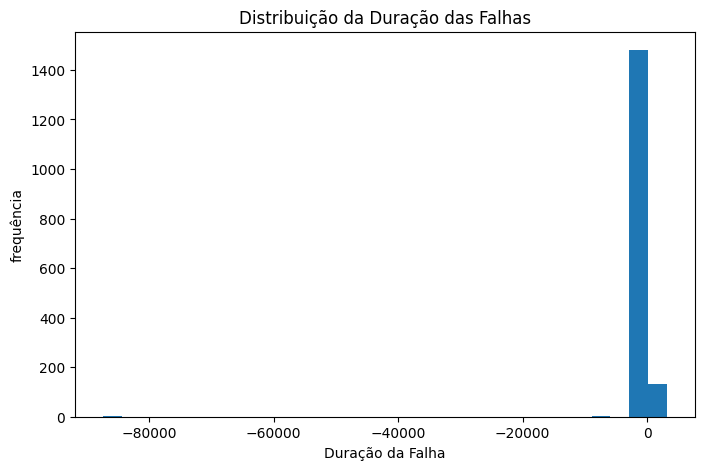

In [16]:
#HISTOGRAMA (DISTRIBUIÇÃO E DURAÇÃO)

import matplotlib.pyplot as plt  #importa a biblioteca e plt é o apelido
plt.figure(figsize = (8,5))      # define o tamanho da figura
plt.hist(df['OUTAGE.DURATION'].dropna(), bins = 30) # divide os dados usados em 30 faixas

plt.title('Distribuição da Duração das Falhas') # titulo
plt.xlabel('Duração da Falha') # nome do eixo horizontal
plt.ylabel('frequência') # nome do eixo vertical

plt.show() # mostra o grafico

In [ ]:
# grafico de bloxpot
sns.boxplot(y=df['OUTAGE.DURATION'])
plt.title('Distribuição da Duração das Falhas (Boxplot)')
plt.ylabel('Duração (horas)')
plt.show()

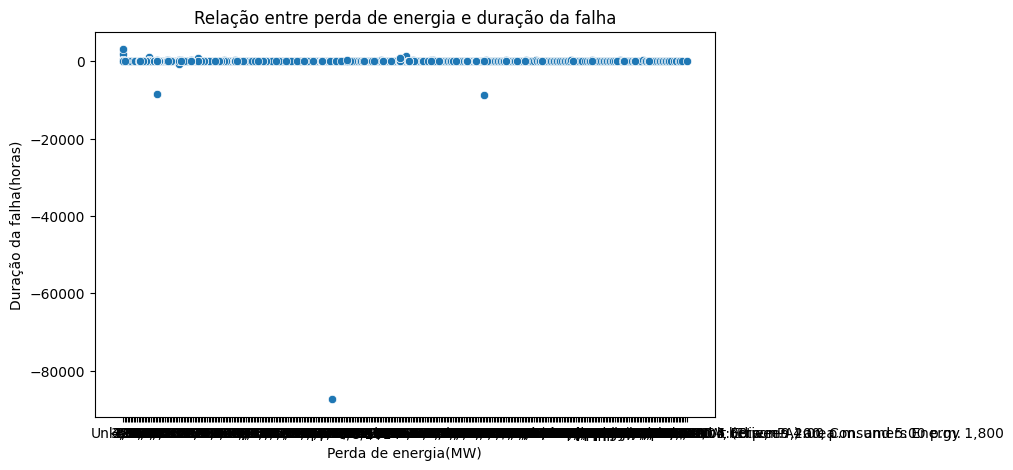

In [19]:
# Codigo do grafico de dispersão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8,5))

sns.scatterplot(x=df['Demand Loss (MW)'], y= df['OUTAGE.DURATION'])

plt.title('Relação entre perda de energia e duração da falha')
plt.xlabel('Perda de energia(MW)')
plt.ylabel('Duração da falha(horas)')

plt.show()

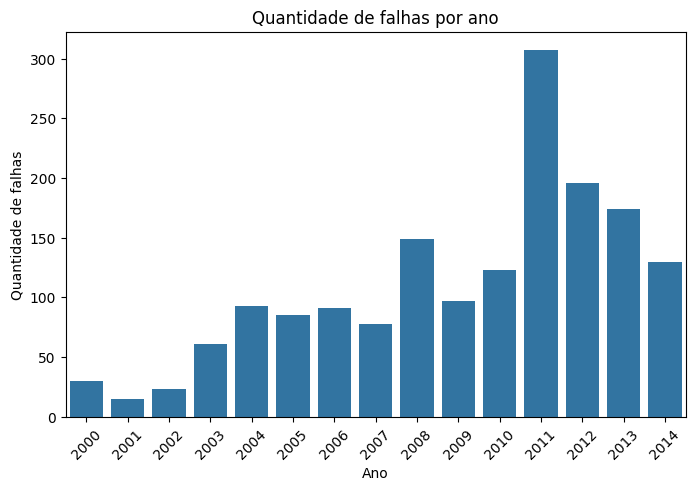

In [21]:
# codigo do grafico de barras
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x=df['Year'])

plt.title('Quantidade de falhas por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de falhas')

plt.xticks(rotation=45) #gira os anos para nao amontoar

plt.show()

In [ ]:
# criar a variavel total de falhas por ano, agrupando os dados por ano

falhas_por_ano = df.groupby('Year').size()



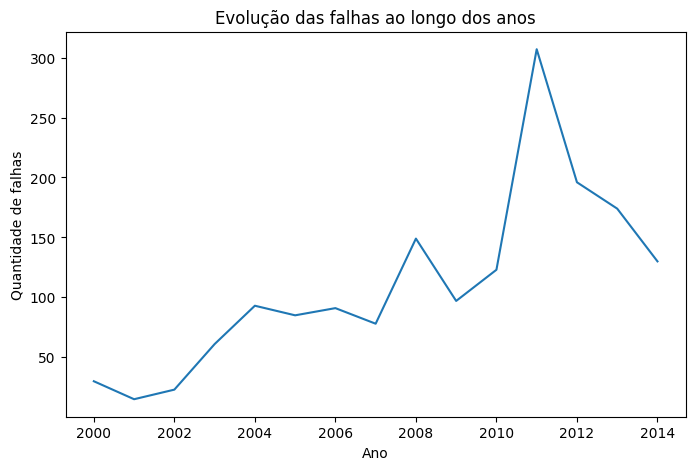

In [25]:
# linha de evolução do tempo

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.lineplot(x=falhas_por_ano.index, y =falhas_por_ano.values) #cria linha ligando os pontos e mostra a relação subindo ou descendo

plt.title('Evolução das falhas ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Quantidade de falhas')

plt.show()

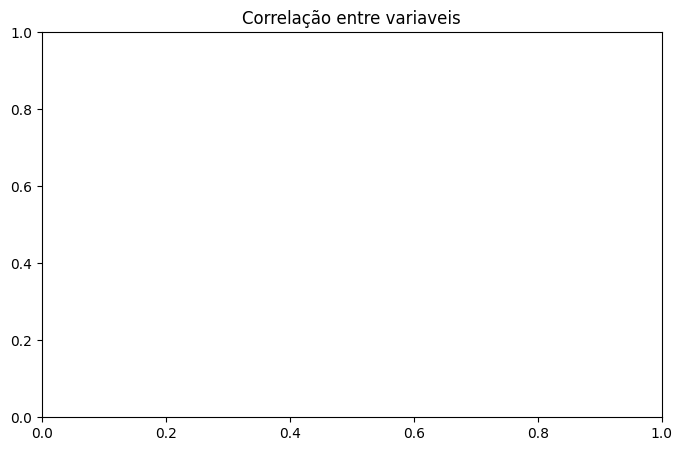

In [27]:
# grafico de heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# converter colunas para número, o erros = coerce faz o unknown(vazio) virar numeros
df['Demand Loss (MW)'] = pd.to_numeric(df['Demand Loss (MW)'], errors='coerce')
df['Number of Customers Affected'] = pd.to_numeric(df['Number of Customers Affected'], errors='coerce')

# agora calcular correlação
correlacao = df[['Demand Loss (MW)', 'Number of Customers Affected', 'OUTAGE.DURATION']].corr()

plt.title('Correlação entre variaveis')

plt.show()